In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from itertools import cycle

In [8]:
# Thiết lập các tham số
IMG_SIZE = 128      # Giảm để tránh crash
BATCH_SIZE = 16
EPOCHS = 30

# Đường dẫn dữ liệu
train_path = "../Data_Final/train"
val_path   = "../Data_Final/val"
test_path  = "../Data_Final/test"

In [9]:
# Kiểm tra GPU
print("GPU khả dụng: ", tf.config.list_physical_devices('GPU'))
print("Phiên bản TensorFlow:", tf.__version__)

GPU khả dụng:  []
Phiên bản TensorFlow: 2.20.0


In [10]:
# Tăng cường dữ liệu cho tập train
train_gen = ImageDataGenerator(
    rescale=1./255,
    # Giảm bias hình dạng / kích thước
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    # Giảm bias màu sắc
    brightness_range=[0.7, 1.3],
    channel_shift_range=30.0
)

# Chỉ rescale cho tập validation và test
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

# Nạp dữ liệu
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(f"\nSố lượng lớp: {train_data.num_classes}")
print(f"Nhãn các lớp: {train_data.class_indices}")

Found 1966 images belonging to 2 classes.


Found 420 images belonging to 2 classes.
Found 424 images belonging to 2 classes.

Số lượng lớp: 2
Nhãn các lớp: {'fresh': 0, 'rotten': 1}


In [12]:
# Xây dựng mô hình CNN Sequential
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(train_data.num_classes, activation='softmax'))
model.build((None, IMG_SIZE, IMG_SIZE, 3))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,454,786 (5.55 MB)

 Trainable params: 1,454,338 (5.55 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Mô hình đã được biên dịch thành công!")

Mô hình đã được biên dịch thành công!


In [14]:
# Thiết lập các callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Tạo thư mục để lưu mô hình
os.makedirs("../models", exist_ok=True)

checkpoint = ModelCheckpoint(
    "../models/sequential_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

print("Đã cấu hình callbacks")

Đã cấu hình callbacks


In [15]:
# Huấn luyện mô hình
start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Tính tổng thời gian huấn luyện
end_time = time.time()
print(f"Tổng thời gian huấn luyện: {end_time - start_time:.2f} giây")

Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.6797 - loss: 0.8100
Epoch 1: val_accuracy improved from None to 0.45952, saving model to ../models/sequential_best.keras

Epoch 1: finished saving model to ../models/sequential_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 42s 321ms/step - accuracy: 0.7935 - loss: 0.4994 - val_accuracy: 0.4595 - val_loss: 0.6828 - learning_rate: 1.0000e-04
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8813 - loss: 0.3449
Epoch 2: val_accuracy did not improve from 0.45952
123/123 ━━━━━━━━━━━━━━━━━━━━ 32s 256ms/step - accuracy: 0.9028 - loss: 0.2691 - val_accuracy: 0.4595 - val_loss: 1.4272 - learning_rate: 1.0000e-04
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9344 - loss: 0.1747
Epoch 3: val_accuracy did not improve from 0.45952
123/123 ━━━━━━━━━━━━━━━━━━━━ 32s 256ms/step - accuracy: 0.9374 - loss: 0.1653 - val_accuracy: 0.4595 - val_loss: 1.2468 - learning_rate: 1.0000e-04
Epoch 4/30
123/123 ━━━

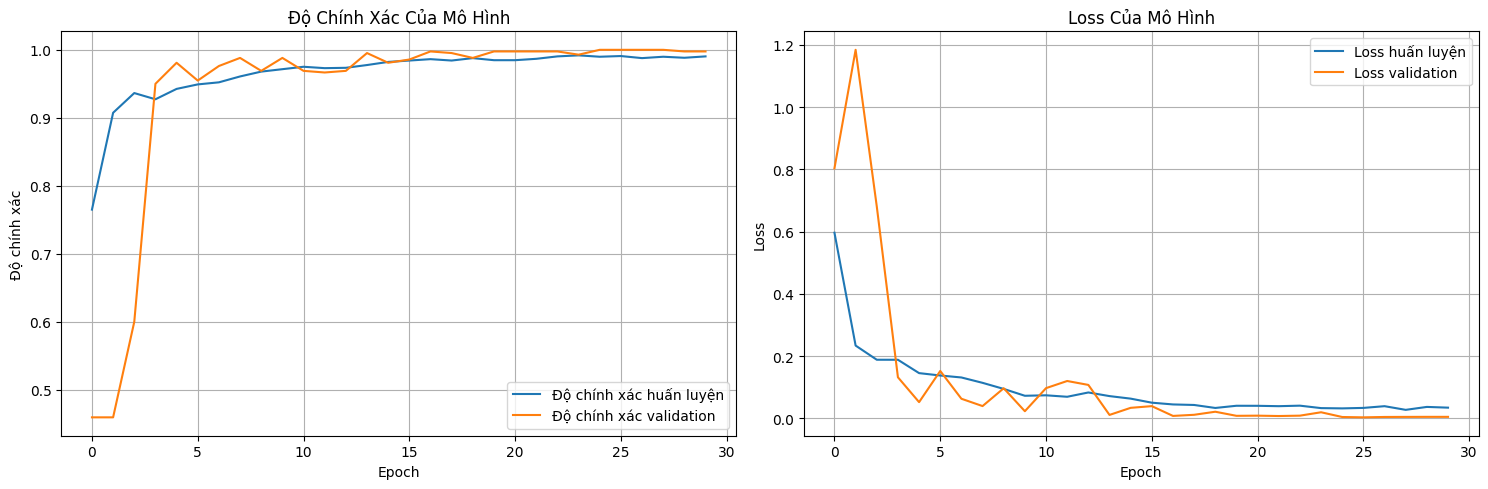

In [ ]:
# Vẽ biểu đồ quá trình huấn luyện
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Vẽ biểu đồ độ chính xác
ax1.plot(history.history['accuracy'], label='Độ chính xác huấn luyện')
ax1.plot(history.history['val_accuracy'], label='Độ chính xác validation')
ax1.set_title('Độ Chính Xác Của Mô Hình')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Độ chính xác')
ax1.legend()
ax1.grid(True)

# Vẽ biểu đồ loss
ax2.plot(history.history['loss'], label='Loss huấn luyện')
ax2.plot(history.history['val_loss'], label='Loss validation')
ax2.set_title('Loss Của Mô Hình')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Đánh giá trên tập test
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)

print(f"\nLoss trên tập test: {test_loss:.4f}")
print(f"Độ chính xác trên tập test: {test_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9929 - loss: 0.0213

Loss trên tập test: 0.0213
Độ chính xác trên tập test: 0.9929


In [ ]:
# Dự đoán
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

Classification Report:

              precision    recall  f1-score   support

       fresh       0.98      1.00      0.99       195
      rotten       1.00      0.99      0.99       229

    accuracy                           0.99       424
   macro avg       0.99      0.99      0.99       424
weighted avg       0.99      0.99      0.99       424



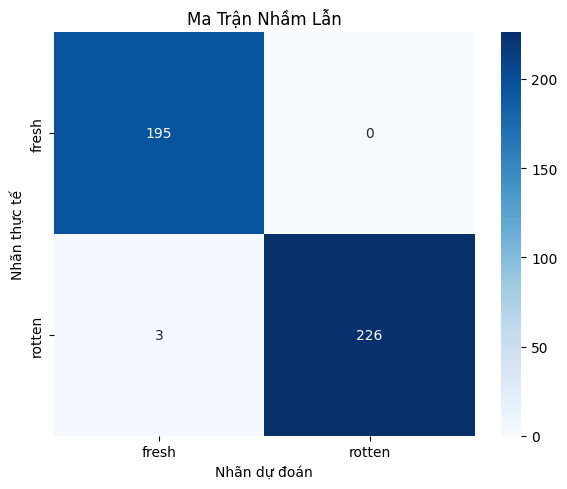


Độ Chính Xác Từng Lớp:
fresh: 100.00%
rotten: 98.69%


In [ ]:
# Vẽ ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Ma Trận Nhầm Lẫn')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

# In độ chính xác cho từng lớp
print("\nĐộ Chính Xác Từng Lớp:")
for i, class_name in enumerate(class_names):
    class_accuracy = cm[i, i] / cm[i].sum() * 100
    print(f"{class_name}: {class_accuracy:.2f}%")

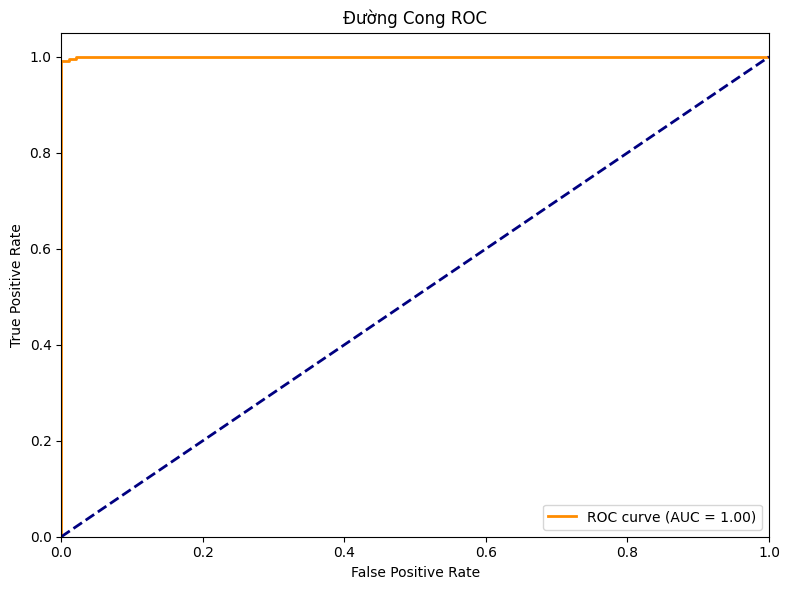

In [ ]:
# ROC CURVE
fpr, tpr, _ = roc_curve(true_classes, predictions[:, 1])
roc_auc_score = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường Cong ROC')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



Số ảnh dự đoán sai: 3


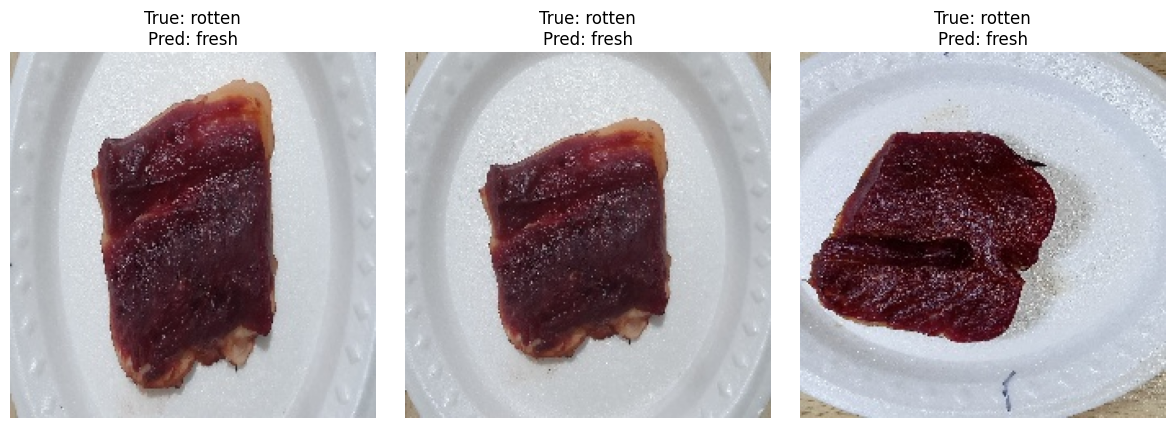

In [ ]:
# ERROR ANALYSIS
misclassified = np.where(predicted_classes != true_classes)[0]
print(f"\nSố ảnh dự đoán sai: {len(misclassified)}")

plt.figure(figsize=(12,12))
for i, idx in enumerate(misclassified[:9]):
    img_path = test_data.filepaths[idx]
    img = plt.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_classes[idx]]}\nPred: {class_names[predicted_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Lưu mô hình cuối cùng
model.save('../models/sequential_final.keras')
model.save('../models/sequential_final.h5')

print("\nĐã lưu mô hình thành công!")


Đã lưu mô hình thành công!
